In [ ]:
import pandas as pd

file_path = "/content/Vietnam Hotel Reviews Limited.xlsx"
df = pd.read_excel(file_path) # Use pd.read_csv for CSV files

cleaned_df = df[[
    'username',     # Reviewer
    'stayDate',     # Date and platform
    'rating',     # Rating
    'text',
    'hotelName',
    'language'# text
]].copy()

cleaned_df.columns = ['Reviewer', 'date', 'rating', 'text','Hotel Name','language']

cleaned_df.dropna(subset=['text'], inplace=True)

cleaned_df.reset_index(drop=True, inplace=True)

output_path = "cleaned_google_reviews.xlsx"
cleaned_df.to_excel(output_path, index=False)

print(f"Cleaned data saved to: {output_path}")

Cleaned data saved to: cleaned_google_reviews.xlsx


In [ ]:
import pandas as pd
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import style
style.use('ggplot')
from textblob import TextBlob
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from google.colab import drive


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
file_path = '/content/cleaned_google_reviews.xlsx'

In [ ]:
df = pd.read_excel('/content/cleaned_google_reviews.xlsx')

In [ ]:
df

,Reviewer,date,rating,text,Hotel Name,language
0,唐次次,2018-09-30,5,早餐真的超级棒，度假村有私人沙滩，无边泳池。拍照超好看，游客很少，大部分都是外国人，拍照完全...,Khu Nghỉ Dưỡng Fusion Resort Phú Quốc,zhCN
1,maru0902,2016-09-30,5,방도 너무나 맘에들고 전경도 멋집니다 디자인이 무심한듯 디테일하게 꾸미신것같아요 ㅋ...,Sy's Homestay,ko
2,Companion08015327562,2019-04-30,5,超美，服务超级好，每位服务人员都很好，还会再来，特别适合亲子，好喜欢这里，基本上所有的服务都...,Vinpearl Discovery Coastalland Phú Quốc,zhCN
3,Trek45683693309,2019-06-30,5,非常非常棒的度假选择，吹着海风，听着音乐，吃着美食。看着沙滩海浪，蓝天白云，瞬间放空自己的一...,The Anam,zhCN
4,荘哥哥,2018-10-31,5,4天3晚，很紧凑，真的是玩嗨了，吃的、玩的，全程五服务，非常非常好，一定要有中文服务非常方便...,VinOasis Phu Quoc,zhCN
...,...,...,...,...,...,...
62323,TravellingVolup,2017-08-31,5,This review is slightly overdue; I have been t...,JW Marriott Phu Quoc Emerald Bay Resort & Spa,en
62324,baklagin1986,2022-02-28,5,Хочется оставить более менее подробный отзыв о...,Khu Nghỉ Dưỡng Cam Ranh Riviera,ru
62325,emanuelaboh,2019-01-31,5,"..non è un binomio semplice da creare, e propr...",Peppercorn Beach Resort,it
62326,surik0va,2017-03-31,5,Всем дорброго времени суток! Вернулись из отел...,Khu Nghỉ Dưỡng Cam Ranh Riviera,ru


In [ ]:
!pip install deep-translator

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 2.8 MB/s eta 0:00:00


In [ ]:
import pandas as pd
from deep_translator import GoogleTranslator
from tqdm import tqdm # Progress bar
import time
import os
from google.colab import drive
drive.mount('/content/drive')

# 1. Load Data
file_path = "/content/cleaned_google_reviews.xlsx"
df = pd.read_excel(file_path)

# 1. Create a mapping dictionary for irregular codes
# Add any other codes here that cause errors
fix_codes = {
    'zhCN': 'zh-CN',  # Fix Chinese Simplified
    'zhTW': 'zh-TW',  # Fix Chinese Traditional
    'ms': 'malay'     # Sometimes 'ms' needs to be written out or checked
}

# 2. Apply the fix to your language column
df['language'] = df['language'].replace(fix_codes)

# 3. Handle Unsupported Languages automatically
# This prevents the whole script from stopping if it hits a weird code
def translate_text(row):
    if pd.notna(row["Translated"]):
        return row["Translated"]
    if row['language'] == 'en':
        return row['text']

    try:
        time.sleep(0.2)
        # We wrap this in a try/except to catch "No support" errors
        return GoogleTranslator(source=row['language'], target='en').translate(str(row['text']))
    except Exception as e:
        # If the language is still not supported, it will put "SKIP" in the cell
        # so you can find and fix it later
        print(f"Skipping {row['language']}: {e}")
        return "SKIP"

# 2. Setup
column_to_translate = "text"
# Important: Use your 'language' column instead of 'auto' to speed up processing
lang_column = "language"
target_language = "en"
output_file = "/content/drive/My Drive/translated_output.xlsx"

# Create the column if it doesn't exist
if "Translated" not in df.columns:
    df["Translated"] = None

# 3. Translation Logic with rate-limiting
def translate_text(row):
    # Skip if already translated or if already English
    if pd.notna(row["Translated"]):
        return row["Translated"]
    if row[lang_column] == 'en':
        return row[column_to_translate]

    try:
        # 0.2s delay keeps you under the 5 requests/sec limit
        time.sleep(0.05)
        return GoogleTranslator(source=row[lang_column], target=target_language).translate(str(row[column_to_translate]))
    except Exception as e:
        print(f"Error at row: {e}")
        return None

# 4. Process in Chunks and Save Progress
# Using tqdm to see how long is left
tqdm.pandas()

# We save every 500 rows so you don't lose work if Colab disconnects
chunk_size = 500
for i in range(0, len(df), chunk_size):
    print(f"\nProcessing rows {i} to {i+chunk_size}...")

    # Process the chunk
    df.iloc[i:i+chunk_size, df.columns.get_loc("Translated")] = \
        df.iloc[i:i+chunk_size].progress_apply(translate_text, axis=1)

    # Save backup to Excel
    df.to_excel(output_file, index=False)
    print(f"Progress saved to {output_file}")

print("Translation complete!")

Mounted at /content/drive

Processing rows 0 to 500...


100%|██████████| 500/500 [01:06<00:00,  7.50it/s]


Progress saved to /content/drive/My Drive/translated_output.xlsx

Processing rows 500 to 1000...


100%|██████████| 500/500 [01:15<00:00,  6.58it/s]


Progress saved to /content/drive/My Drive/translated_output.xlsx

Processing rows 1000 to 1500...


...

Error at row: Request exception can happen due to an api connection error. Please check your connection and try again
Error at row: Request exception can happen due to an api connection error. Please check your connection and try again
Error at row: Request exception can happen due to an api connection error. Please check your connection and try again


100%|█████████▉| 327/328 [00:16<00:00, 18.13it/s]

Error at row: Request exception can happen due to an api connection error. Please check your connection and try again


100%|██████████| 328/328 [00:16<00:00, 19.59it/s]


Error at row: Request exception can happen due to an api connection error. Please check your connection and try again
Progress saved to /content/drive/My Drive/translated_output.xlsx
Translation complete!


In [ ]:
text_df = df.drop(
    ['date', 'rating','Reviewer'],
    axis=1,
    errors='ignore'
)



In [ ]:
df.columns

Index(['Reviewer', 'date', 'rating', 'text', 'Hotel Name', 'language',
       'Translated'],
      dtype='object')

In [ ]:
text_df.head()

,text,Hotel Name,language,Translated
0,早餐真的超级棒，度假村有私人沙滩，无边泳池。拍照超好看，游客很少，大部分都是外国人，拍照完全...,Khu Nghỉ Dưỡng Fusion Resort Phú Quốc,zh-CN,The breakfast is really great. The resort has ...
1,방도 너무나 맘에들고 전경도 멋집니다 디자인이 무심한듯 디테일하게 꾸미신것같아요 ㅋ...,Sy's Homestay,ko,I really like the room and the view is great. ...
2,超美，服务超级好，每位服务人员都很好，还会再来，特别适合亲子，好喜欢这里，基本上所有的服务都...,Vinpearl Discovery Coastalland Phú Quốc,zh-CN,"Super beautiful, the service is super good, ev..."
3,非常非常棒的度假选择，吹着海风，听着音乐，吃着美食。看着沙滩海浪，蓝天白云，瞬间放空自己的一...,The Anam,zh-CN,"A very, very good vacation choice, blowing the..."
4,4天3晚，很紧凑，真的是玩嗨了，吃的、玩的，全程五服务，非常非常好，一定要有中文服务非常方便...,VinOasis Phu Quoc,zh-CN,"4 days and 3 nights, very compact, really fun,..."


In [ ]:
df.isnull().sum()

,0
Reviewer,465
date,0
rating,0
text,0
Hotel Name,0
language,0
Translated,72


In [ ]:
df = df.dropna()

In [ ]:
df.isnull().sum()

,0
Reviewer,0
date,0
rating,0
text,0
Hotel Name,0
language,0
Translated,0


In [ ]:
print(text_df['Translated'].iloc[0], "\n")
print(text_df['Translated'].iloc[1], "\n")
print(text_df['Translated'].iloc[2], "\n")
print(text_df['Translated'].iloc[3], "\n")
print(text_df['Translated'].iloc[4], "\n")

The breakfast is really great. The resort has a private beach and infinity pool. The photos are great. There are very few tourists, most of them are foreigners, so there is no impact at all on taking photos. 

I really like the room and the view is great. The design seems to have been decorated with great detail, as if it was indifferent haha. 

Super beautiful, the service is super good, every service staff is very nice, I will come again, especially suitable for parents and children, I really like this place, basically all the services can be satisfied 

A very, very good vacation choice, blowing the sea breeze, listening to music, and eating delicious food. Looking at the beach, waves, blue sky and white clouds, I instantly let go of everything. . . 

4 days and 3 nights, very compact, really fun, food, entertainment, five services throughout the journey, very, very good, must have Chinese service, very convenient. Thanks! 



In [ ]:
import nltk
import pandas as pd
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import nltk
nltk.download('punkt_tab')

nltk.download('punkt')
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def data_processing(text):
    if not isinstance(text, str):
        text = str(text)
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", '', text, flags=re.MULTILINE)
    text = re.sub(r'@\w+|\#', '', text)
    text = re.sub(r'[^\w\s]', '', text)

    try:
        text_tokens = word_tokenize(text)
    except LookupError:
        nltk.download('punkt')
        text_tokens = word_tokenize(text)

    filtered_text = [w for w in text_tokens if w not in stop_words]
    return " ".join(filtered_text)

text_df['Translated'] = text_df['Translated'].apply(data_processing)


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
from nltk.stem import PorterStemmer
stemmer = PorterStemmer()

In [ ]:
def stemming(data):
    text = [stemmer.stem(word) for word in data]
    return text

In [ ]:
print(text_df['Translated'].iloc[0], "\n")
print(text_df['Translated'].iloc[1], "\n")
print(text_df['Translated'].iloc[2], "\n")
print(text_df['Translated'].iloc[3], "\n")
print(text_df['Translated'].iloc[4], "\n")

breakfast really great resort private beach infinity pool photos great tourists foreigners impact taking photos 

really like room view great design seems decorated great detail indifferent haha 

super beautiful service super good every service staff nice come especially suitable parents children really like place basically services satisfied 

good vacation choice blowing sea breeze listening music eating delicious food looking beach waves blue sky white clouds instantly let go everything 

4 days 3 nights compact really fun food entertainment five services throughout journey good must chinese service convenient thanks 



In [ ]:
def polarity(text): #dictionary sentiment
  return TextBlob(text).sentiment.polarity

In [ ]:
text_df['polarity'] = text_df['Translated'].apply(polarity)

In [ ]:
text_df.head()

,Reviewer,date,text,Hotel Name,language,Translated,polarity,sentiment
0,唐次次,2018-09-30,早餐真的超级棒度假村有私人沙滩无边泳池拍照超好看游客很少大部分都是外国人拍照完全没影响,Khu Nghỉ Dưỡng Fusion Resort Phú Quốc,zh-CN,breakfast really great resort private beach in...,0.533333,Neutral
1,maru0902,2016-09-30,방도 너무나 맘에들고 전경도 멋집니다 디자인이 무심한듯 디테일하게 꾸미신것같아요 ㅋ...,Sy's Homestay,ko,really like room view great design seems decor...,0.500000,Neutral
2,Companion08015327562,2019-04-30,超美服务超级好每位服务人员都很好还会再来特别适合亲子好喜欢这里基本上所有的服务都可以满足,Vinpearl Discovery Coastalland Phú Quốc,zh-CN,super beautiful service super good every servi...,0.564583,Neutral
3,Trek45683693309,2019-06-30,非常非常棒的度假选择吹着海风听着音乐吃着美食看着沙滩海浪蓝天白云瞬间放空自己的一切,The Anam,zh-CN,good vacation choice blowing sea breeze listen...,0.340000,Neutral
4,荘哥哥,2018-10-31,4天3晚很紧凑真的是玩嗨了吃的玩的全程五服务非常非常好一定要有中文服务非常方便谢谢,VinOasis Phu Quoc,zh-CN,4 days 3 nights compact really fun food entert...,0.300000,Neutral


In [ ]:
def sentiment (label):
  if label <0:
    return "Negative"
  elif label == 0:
    return "Neutral"
  elif label >0:
    return "Positive"

In [ ]:
text_df['sentiment'] = text_df['polarity'].apply(sentiment)

In [ ]:
text_df.head(15)

,Reviewer,date,text,Hotel Name,language,Translated,polarity,sentiment
0,唐次次,2018-09-30,早餐真的超级棒度假村有私人沙滩无边泳池拍照超好看游客很少大部分都是外国人拍照完全没影响,Khu Nghỉ Dưỡng Fusion Resort Phú Quốc,zh-CN,breakfast really great resort private beach in...,0.533333,Positive
1,maru0902,2016-09-30,방도 너무나 맘에들고 전경도 멋집니다 디자인이 무심한듯 디테일하게 꾸미신것같아요 ㅋ...,Sy's Homestay,ko,really like room view great design seems decor...,0.500000,Positive
2,Companion08015327562,2019-04-30,超美服务超级好每位服务人员都很好还会再来特别适合亲子好喜欢这里基本上所有的服务都可以满足,Vinpearl Discovery Coastalland Phú Quốc,zh-CN,super beautiful service super good every servi...,0.564583,Positive
3,Trek45683693309,2019-06-30,非常非常棒的度假选择吹着海风听着音乐吃着美食看着沙滩海浪蓝天白云瞬间放空自己的一切,The Anam,zh-CN,good vacation choice blowing sea breeze listen...,0.340000,Positive
4,荘哥哥,2018-10-31,4天3晚很紧凑真的是玩嗨了吃的玩的全程五服务非常非常好一定要有中文服务非常方便谢谢,VinOasis Phu Quoc,zh-CN,4 days 3 nights compact really fun food entert...,0.300000,Positive
5,Traveler50408596574,2019-06-30,不错的地方海水很清澈服务也很到位服务员都很热情酒店有两个餐厅在海边可以看着海景吃吃饭聊聊天,The Anam,zh-CN,nice place water clear service excellent waite...,0.575000,Positive
6,namnghindong,2009-04-30,belle terrasse au 4ème étage avec vue sur le m...,Khách sạn Du lịch Hàm Luông,fr,beautiful terrace 4th floor view mekong,0.850000,Positive
7,Companion14239830914,2019-02-28,酒店特别大气服务态度很好特别前台接待员燕珍普通话服务沟通交流到位我们十分满意餐饮服务的也很好,Vinpearl Discovery Greenhill Phú Quốc,zh-CN,hotel grand service attitude good particular f...,0.513333,Positive
8,Donghyun K,2017-09-30,객실 위치는 다낭시내에서 멀기때문에 나쁜편이지만 리조트 내에서 쉬다 오실분들에게는 ...,Banyan Tree Lang Co,ko,location room bad far da nang city best want r...,0.133333,Positive
9,789yuang,2017-06-30,とても良い思い出になりました全て満足していてできればまた行きたいです料理サービスの品質最高です,Khách sạn Nam Hải Hội An,ja,good memory satisfied everything would like go...,0.425000,Positive


In [ ]:
text_df.to_csv('/content/cleaned_google_reviews.xlsx', index=False)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
text_df['Translated']=text_df['Translated'].astype(str)

In [ ]:
tfidf = TfidfVectorizer(max_features=10)

In [ ]:
tfidf_matrix = tfidf.fit_transform(text_df['Translated'])

In [ ]:
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf.get_feature_names_out())

In [ ]:
tfidf_df.head(10)

,beach,food,good,great,hotel,pool,resort,room,staff,us
0,0.404358,0.000000,0.000000,0.729654,0.000000,0.38032,0.399321,0.000000,0.000000,0.0
1,0.000000,0.000000,0.000000,0.902563,0.000000,0.00000,0.000000,0.430557,0.000000,0.0
2,0.000000,0.000000,0.768878,0.000000,0.000000,0.00000,0.000000,0.000000,0.639396,0.0
3,0.646924,0.541791,0.536612,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.0
4,0.000000,0.710495,0.703702,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.0
5,0.759322,0.000000,0.000000,0.000000,0.650715,0.00000,0.000000,0.000000,0.000000,0.0
6,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.0
7,0.000000,0.000000,0.888461,0.000000,0.458951,0.00000,0.000000,0.000000,0.000000,0.0
8,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.753822,0.657078,0.000000,0.0
9,0.000000,0.710495,0.703702,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.0


sentiment

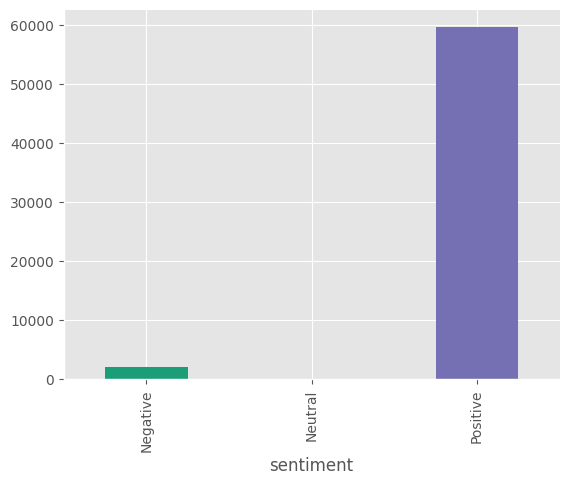

In [ ]:
#@title sentiment

from matplotlib import pyplot as plt
import seaborn as sns
text_df.groupby('sentiment').size().plot(kind='bar', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top','right']].set_visible(False)

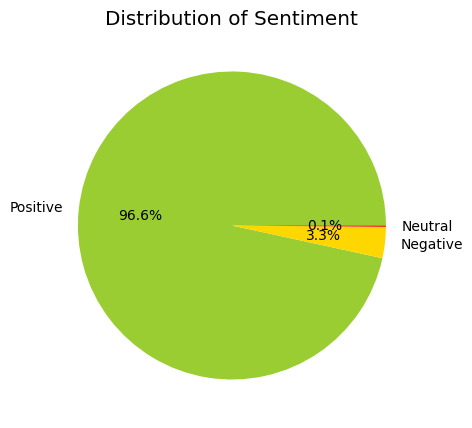

In [ ]:
fig = plt.figure(figsize=(5,5))
colour = ("yellowgreen", "gold", "red")
plt.pie(text_df['sentiment'].value_counts(), labels=text_df['sentiment'].value_counts().index, colors=colour, autopct='%1.1f%%')
plt.title ('Distribution of Sentiment')
plt.show()

In [ ]:
columns_to_drop = ['date', 'rating']
existing_columns = [col for col in columns_to_drop if col in df.columns]
text_df = df.drop(existing_columns,axis=1)

In [ ]:
# Existing data_processing function
def data_processing(text):
    if not isinstance(text, str):
        text = str(text)
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", '', text, flags=re.MULTILINE)
    text = re.sub(r'@\w+|\#', '', text)
    text = re.sub(r'[^\w\s]', '', text)

    try:
        text_tokens = word_tokenize(text)
    except LookupError:
        nltk.download('punkt')
        text_tokens = word_tokenize(text)

    filtered_text = [w for w in text_tokens if w not in stop_words]
    return " ".join(filtered_text)



df['Translated'] = df['Translated'].apply(data_processing)

def polarity(text):
    return TextBlob(text).sentiment.polarity

def sentiment(label):
    if label < 0:
        return "Negative"
    elif label == 0:
        return "Neutral"
    elif label > 0:
        return "Positive"

df['polarity'] = df['Translated'].apply(polarity)
df['sentiment'] = df['polarity'].apply(sentiment)


columns_to_drop = ['Date', 'rating']
existing_columns = [col for col in columns_to_drop if col in df.columns]
text_df = df.drop(existing_columns, axis=1)



neu_review = text_df[text_df['sentiment'] == 'Neutral']
neu_review = neu_review.sort_values(by='polarity', ascending=False)
neu_review.head(15)

,Reviewer,date,text,Hotel Name,language,Translated,polarity,sentiment
85,junone65,2020-01-31,가족들과 함께 빈펄의 정수와 깨끗함 아름다움을 느끼고 돌아갑니다 감사합니다 다음에도...,Meliá Vinpearl Cam Ranh Beach Resort,ko,returned home feeling essence cleanliness beau...,0.0,Neutral
126,timhailstone,2012-01-31,indochine reminds staying soviet hotel 40 year...,Indochine hotel,en,indochine reminds staying soviet hotel 40 year...,0.0,Neutral
169,윤진 이,2016-04-30,방청소 요청을 하여도 않해주었고 옷장은 먼지 구덩이에 아주 불친절한 호텔 입니다 프...,Dong A Hotel 1,ko,even asked room cleaned didnt closet dust pit ...,0.0,Neutral
478,rangoonBrussels,2008-08-31,un havre de paix de nature de silence de luxe ...,Le Domaine de Tam Hải,fr,peace nature silence luxury beauty,0.0,Neutral
616,현기 도,2022-07-31,한국의 신라호텔급 아닙니다 저가의 홈쇼핑 고객이 조식 식당에 가득함 신라호텔 브랜드...,Shilla Monogram Quangnam Danang,ko,like shilla hotel korea lowcost home shopping ...,0.0,Neutral
861,HyuckJoonLee,2019-07-31,도심에서 불과 10분 거리에 있는데 완전 숲속에서 휴양을 하는 느낌이다 90년된 건...,Ana Mandara Villas Dalat Resort & Spa,ko,10 minutes city center feels like youre comple...,0.0,Neutral
959,Ji Woo K,2018-01-31,ᴡᴇ ᴀʀᴇ ᴠᴇʀʏ ʜᴀᴘᴘʏ ᴡʜᴇɴ ᴡᴇ sᴛᴀʏ ɪɴ ʙɪɴ ᴘᴇᴀʀʟ ᴛʜ...,Meliá Vinpearl Cam Ranh Beach Resort,ko,ᴡᴇ ᴀʀᴇ ᴠᴇʀʏ ʜᴀᴘᴘʏ ᴡʜᴇɴ ᴡᴇ sᴛᴀʏ ɪɴ ʙɪɴ ᴘᴇᴀʀʟ ᴛʜ...,0.0,Neutral
1273,manabu12,2016-09-30,ビーチビラで6泊ゆったりした時間のなか庭のプールで泳いだりルームサービスを楽しんだり至れり尽...,Banyan Tree Lang Co,ja,6 nights beach villa take relaxing dip garden ...,0.0,Neutral
2024,Meander62091996433,2019-01-31,service nicedaily breakfast food markets phoun...,Angsana Lang Co Vietnam,en,service nicedaily breakfast food markets phoun...,0.0,Neutral
2046,Денис С,2019-12-31,đặt phòng trên trang web khách sạn yêu cầu đặt...,PhuQuoc EcoLodge,vi,booking room website hotel required 250 deposi...,0.0,Neutral


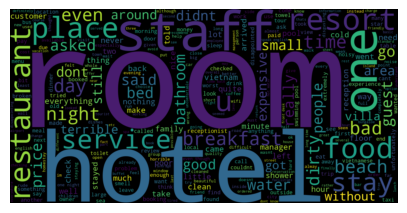

In [ ]:
# Filter text_df for negative reviews
neg_review = text_df[text_df['sentiment'] == 'Negative']

# Now the rest of your code to generate the word cloud will work
Text = ''.join([word for word in neg_review['Translated']])
plt.figure(figsize=(5,5))
wordcloud = WordCloud(max_words=300, width=1600, height=800).generate(Text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

/tmp/ipykernel_1269/2141897193.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), palette='viridis')


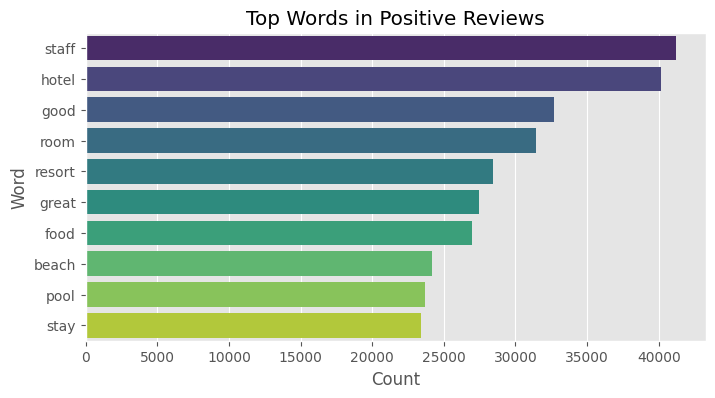

/tmp/ipykernel_1269/2141897193.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), palette='viridis')


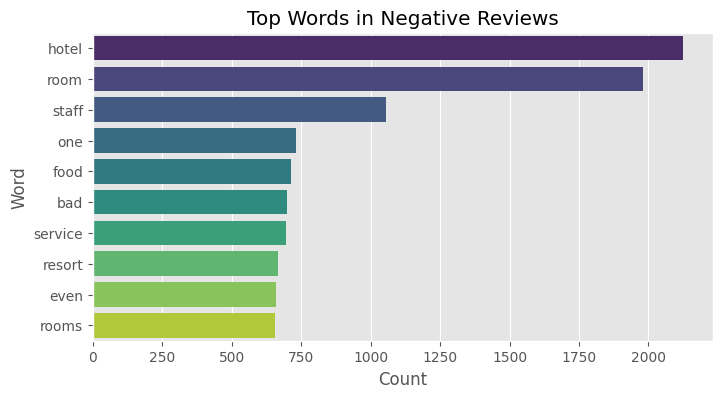

/tmp/ipykernel_1269/2141897193.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), palette='viridis')


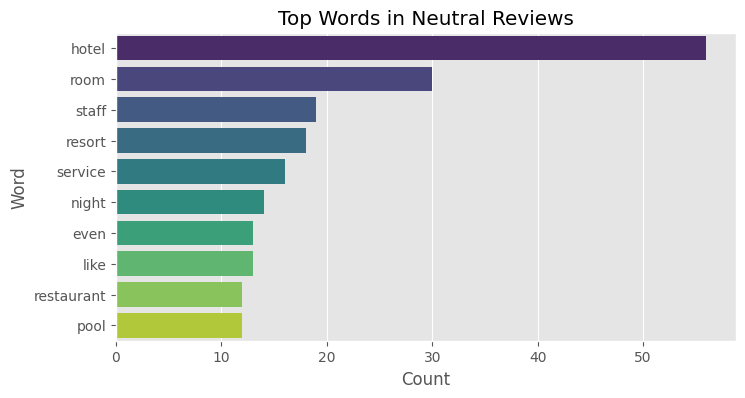

In [ ]:
from collections import Counter
stop_words = set(stopwords.words('english'))

for sentiment in text_df['sentiment'].unique():
    words = " ".join(text_df[text_df['sentiment'] == sentiment]['Translated']).split()
    words = [word for word in words if word not in stop_words and len(word) > 2]
    most_common = Counter(words).most_common(10)

    words, counts = zip(*most_common)
    plt.figure(figsize=(8, 4))
    sns.barplot(x=list(counts), y=list(words), palette='viridis')
    plt.title(f'Top Words in {sentiment.capitalize()} Reviews')
    plt.xlabel('Count')
    plt.ylabel('Word')
    plt.show()


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

vect = CountVectorizer(ngram_range=(1,2))
vect.fit(text_df['Translated'])

feature_names = vect.get_feature_names_out()
print("Number of features: {}\n".format(len(feature_names)))
print("First 20 features:\n{}".format(feature_names[:50]))

Number of features: 1462550

First 20 features:
['00' '00 84' '00 large' '00 noisy' '00 oclock' '00 return' '00 us'
 '00 walk' '000' '000 120' '000 135000' '000 15' '000 200000' '000 30'
 '000 90' '000 accepted' '000 asked' '000 big' '000 cab' '000 coke'
 '000 day' '000 departs' '000 dng' '000 dong' '000 dongs' '000 dvn'
 '000 excellent' '000 fee' '000 good' '000 great' '000 half' '000 happy'
 '000 instant' '000 left' '000 official' '000 per' '000 picked'
 '000 request' '000 ridiculous' '000 saw' '000 special' '000 ticket'
 '000 towel' '000 tried' '000 two' '000 us' '000 vd' '000 vdp' '000 vnd'
 '000 vndday']


In [ ]:
x = text_df['Translated']
y = text_df['sentiment']
x = vect.transform(x)

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
logreg = LogisticRegression()
logreg.fit(x_train, y_train)
logreg.pred = logreg.predict(x_test)
logreg_acc = accuracy_score(y_test, logreg.pred)
print("Logistic Regression Accuracy:", logreg_acc*100)

Logistic Regression Accuracy: 98.20373816651833


In [ ]:
review_counts = df['Hotel Name'].value_counts()
hotels_with_sufficient_reviews = review_counts[review_counts >= 1000].index

highest_rated_hotels = df[df['Hotel Name'].isin(hotels_with_sufficient_reviews)].groupby('Hotel Name')['rating'].mean().sort_values(ascending=False)

print("Hotel(s) with the highest average rating (min 1000 reviews):")
print(highest_rated_hotels.head())

Hotel(s) with the highest average rating (min 150 reviews):
Hotel Name
Vinpearl Discovery Wonderworld Phú Quốc    4.939227
Vinpearl Discovery Coastalland Phú Quốc    4.890049
Meliá Vinpearl Cam Ranh Beach Resort       4.882989
Khu Nghỉ Dưỡng Fusion Resort Phú Quốc      4.846460
Sheraton Phu Quoc Long Beach Resort        4.843663
Name: rating, dtype: float64


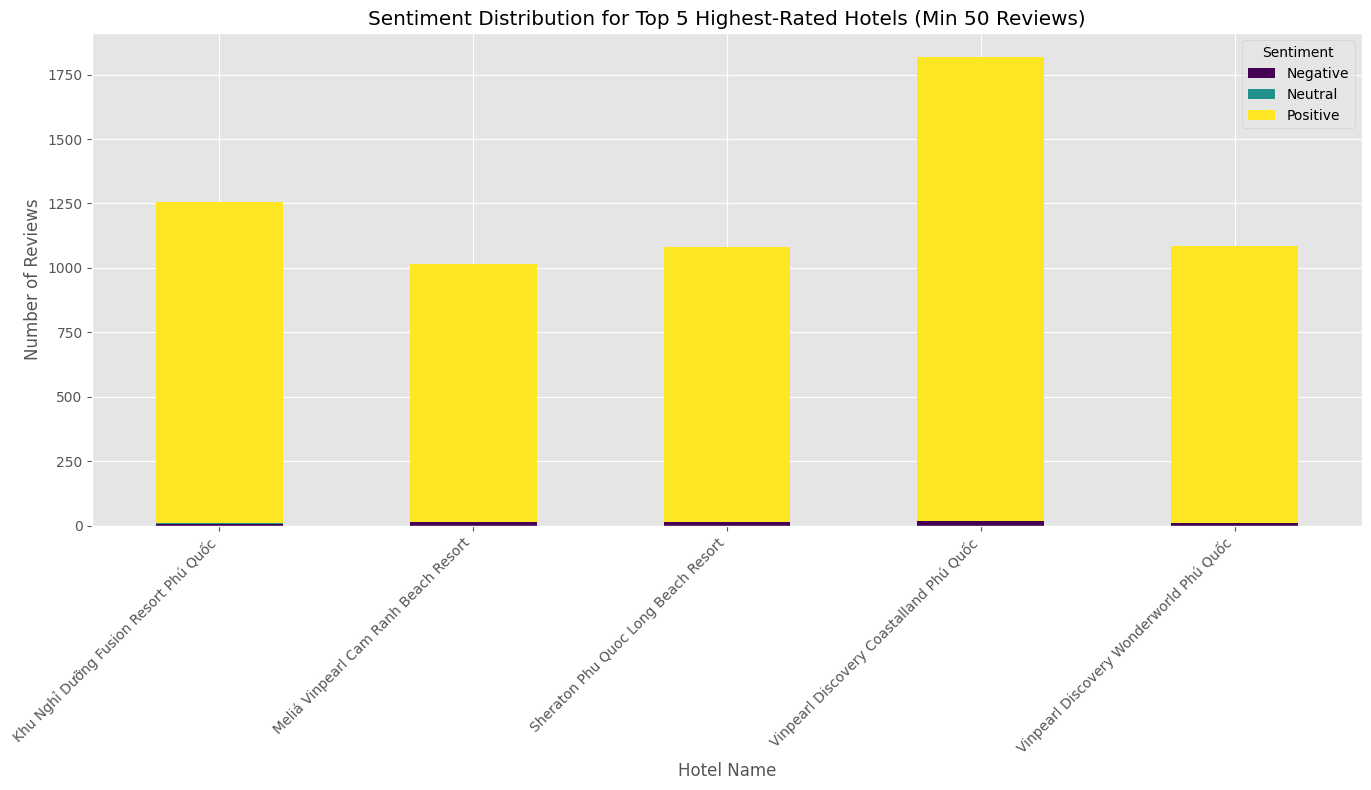

In [ ]:
# Get the names of the top 5 highest-rated hotels
top_5_hotel_names = highest_rated_hotels.head(5).index

# Filter the DataFrame to include only these top 5 hotels
top_5_hotels_df = df[df['Hotel Name'].isin(top_5_hotel_names)]

# Calculate sentiment distribution for these hotels
sentiment_distribution = top_5_hotels_df.groupby(['Hotel Name', 'sentiment']).size().unstack(fill_value=0)

# Ensure all sentiment columns exist for consistent plotting
for s in ['Positive', 'Neutral', 'Negative']:
    if s not in sentiment_distribution.columns:
        sentiment_distribution[s] = 0

# Reorder columns for consistent stacking if desired (e.g., Negative, Neutral, Positive)
sentiment_distribution = sentiment_distribution[['Negative', 'Neutral', 'Positive']]

# Plotting the stacked bar chart
fig = plt.figure(figsize=(14, 8))
sentiment_distribution.plot(kind='bar', stacked=True, colormap='viridis', ax=plt.gca())
plt.title('Sentiment Distribution for Top 5 Highest-Rated Hotels (Min 50 Reviews)')
plt.xlabel('Hotel Name')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()

In [ ]:
# @title step_artifacts
num_fig = "1" # @param {type:"string"}
step = 'DataExploration'  # @param ["DataLoading", "DataExploration", "DataCleaning", "DataWrangling", "DataVisualization", "DataSplitting", "ModelDevelopment", "ModelOptimization", "ModelEvaluation", "Summary"] {type:"string"}
# upload_plt_to_gcs(num_fig, step, fig)

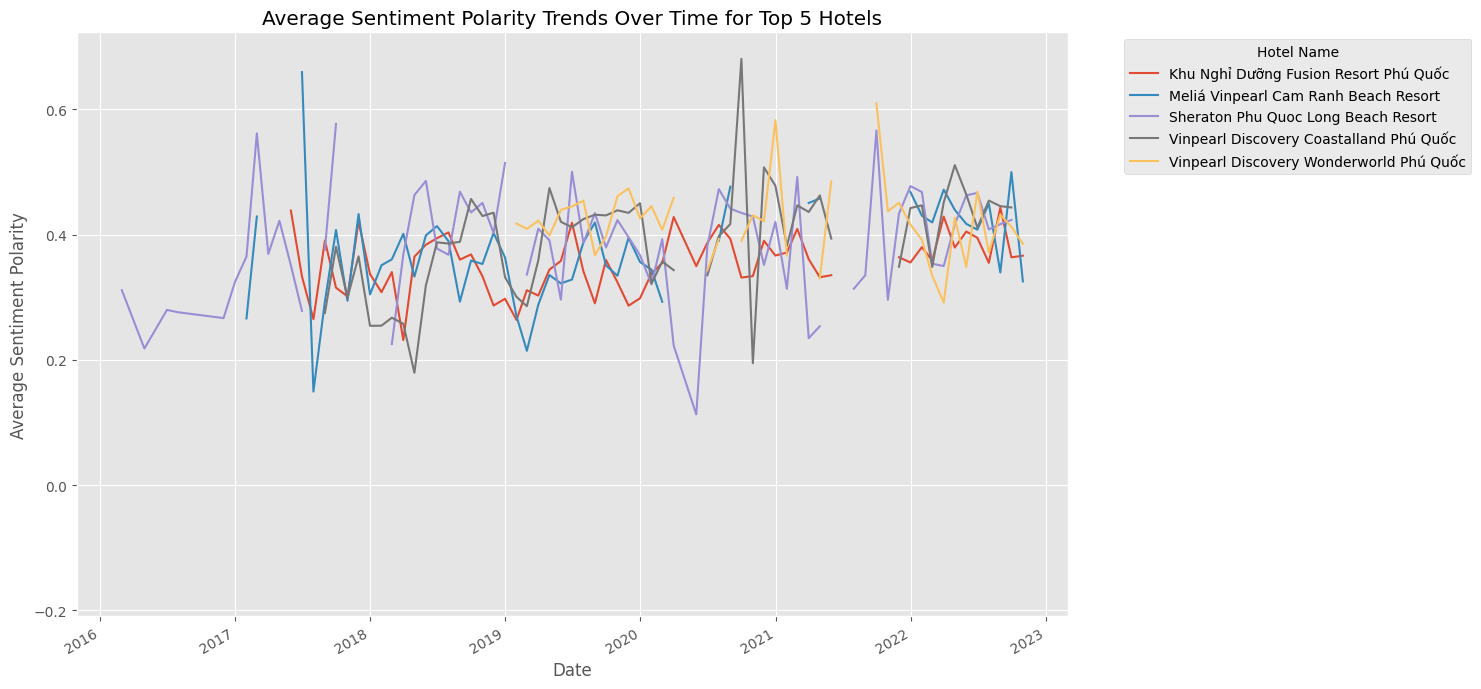

In [ ]:
# Assuming top_5_hotels_df is already defined from the previous step
# (which filters df for the top 5 hotels based on their overall average rating)

# Ensure 'date' is datetime (it should already be from previous steps)
top_5_hotels_df = top_5_hotels_df.copy()
top_5_hotels_df['date'] = pd.to_datetime(top_5_hotels_df['date'])

# Calculate the average polarity for each hotel per day
daily_sentiment_trend = top_5_hotels_df.groupby(['date', 'Hotel Name'])['polarity'].mean().unstack()

# Plot the sentiment trends
fig = plt.figure(figsize=(15, 7))
daily_sentiment_trend.plot(kind='line', ax=plt.gca())
plt.title('Average Sentiment Polarity Trends Over Time for Top 5 Hotels')
plt.xlabel('Date')
plt.ylabel('Average Sentiment Polarity')
plt.grid(True)
plt.legend(title='Hotel Name', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
# @title step_artifacts
num_fig = "2" # @param {type:"string"}
step = 'DataLoading'  # @param ["DataLoading", "DataExploration", "DataCleaning", "DataWrangling", "DataVisualization", "DataSplitting", "ModelDevelopment", "ModelOptimization", "ModelEvaluation", "Summary"] {type:"string"}
# upload_plt_to_gcs(num_fig, step, fig)

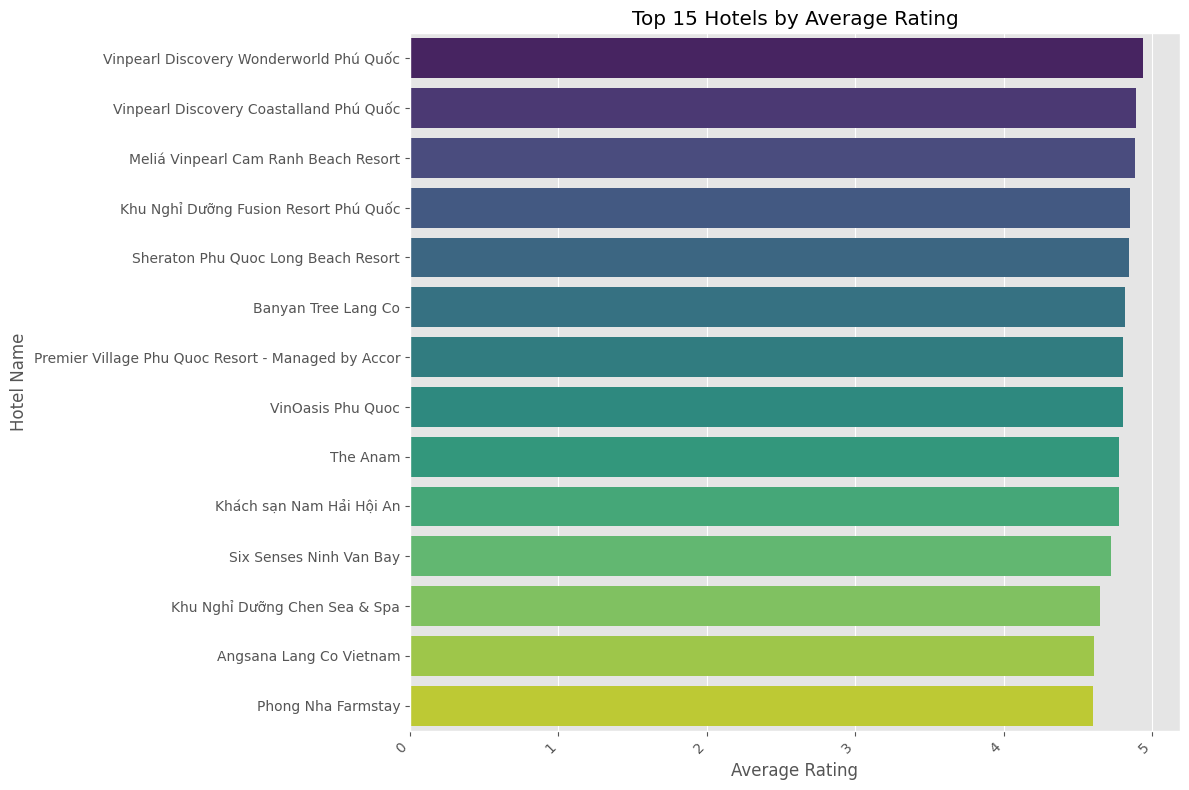

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the top 15 highest-rated hotels
top_15_hotels = highest_rated_hotels.head(15)

plt.figure(figsize=(12, 8))
sns.barplot(x=top_15_hotels.values, y=top_15_hotels.index, hue=top_15_hotels.index, palette='viridis', legend=False)
plt.title('Top 15 Hotels by Average Rating')
plt.xlabel('Average Rating')
plt.ylabel('Hotel Name')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
review_counts = df['Hotel Name'].value_counts()
hotels_with_sufficient_reviews_worst = review_counts[review_counts >= 10].index

worst_rated_hotels = df[df['Hotel Name'].isin(hotels_with_sufficient_reviews_worst)].groupby('Hotel Name')['rating'].mean().sort_values(ascending=True)

print("Hotel(s) with the lowest average rating (min 500 reviews):")
print(worst_rated_hotels.head(15))

Hotel(s) with the lowest average rating (min 500 reviews):
Hotel Name
Hoang Vu Hotel                    1.500000
Thien An Riverside Hotel          2.250000
Viet Hoang Hotel                  2.263158
Thai Ninh Hotel                   2.285714
Gió Biển Resort                   2.300000
Khách sạn Quốc Tế                 2.312500
Sao Mai Hotel                     2.382609
White Palace Hotel                2.500000
Khách sạn Hòa Bình                2.500000
Khách Sạn Mỹ Lan                 2.514706
Long Hai Beach Resort             2.551724
Chân Mây Hotel - Tam Đảo          2.571429
Khách sạn Mường Thanh Lai Châu    2.595745
Central Hotel                     2.620000
Khách sạn Ngọc Hương              2.647059
Name: rating, dtype: float64


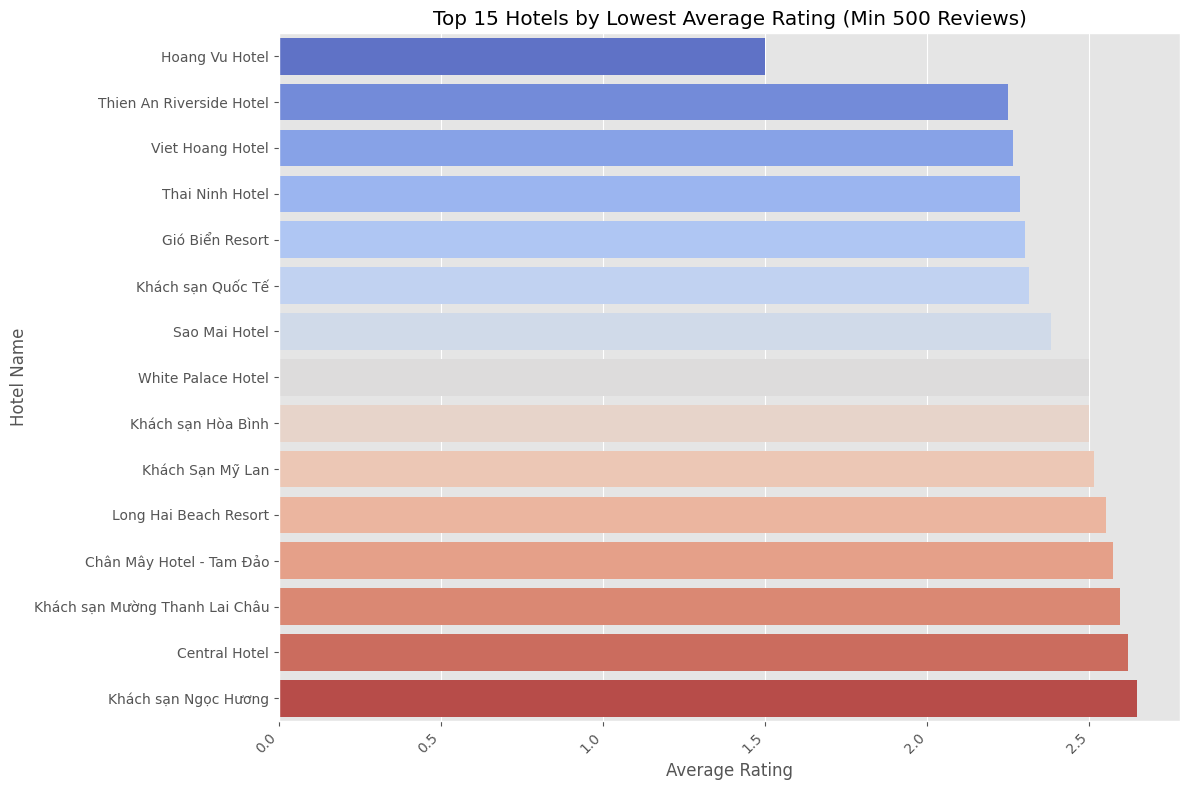

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the top 15 lowest-rated hotels
top_15_worst_hotels = worst_rated_hotels.head(15)

plt.figure(figsize=(12, 8))
sns.barplot(x=top_15_worst_hotels.values, y=top_15_worst_hotels.index, hue=top_15_worst_hotels.index, palette='coolwarm', legend=False)
plt.title('Top 15 Hotels by Lowest Average Rating (Min 500 Reviews)')
plt.xlabel('Average Rating')
plt.ylabel('Hotel Name')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# @title step_artifacts
num_fig = "3" # @param {type:"string"}
step = 'DataVisualization'  # @param ["DataLoading", "DataExploration", "DataCleaning", "DataWrangling", "DataVisualization", "DataSplitting", "ModelDevelopment", "ModelOptimization", "ModelEvaluation", "Summary"] {type:"string"}
# upload_plt_to_gcs(num_fig, step, fig)

In [ ]:
print(confusion_matrix(y_test, logreg.pred))
print ("\n")
print (classification_report(y_test, logreg.pred))

[[  260     0   154]
 [    0     0    19]
 [   49     0 11877]]


              precision    recall  f1-score   support

    Negative       0.84      0.63      0.72       414
     Neutral       0.00      0.00      0.00        19
    Positive       0.99      1.00      0.99     11926

    accuracy                           0.98     12359
   macro avg       0.61      0.54      0.57     12359
weighted avg       0.98      0.98      0.98     12359



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
